# Module 2f — Metadata & Provenance

- **Chapter 2, Module F of 14** — [chapter index](../README.md)
- **Prerequisites:** [2e — Structured Data (CSV, JSON, DB, API)](../2e.%20Structured%20data%20CSV%20JSON%20DB%20API/)
- **Next:** [2g — Cleaning & Normalization](../2g.%20Cleaning%20and%20normalization/)

## The one idea

Modules 2b–2e all answered one question: **what is the text?** This module answers a different
one: **what do we know ABOUT that text?**

A chunk with no metadata can still be retrieved — but it cannot be filtered, cited, dated,
permission-checked, or invalidated when the source changes. Metadata is what turns "here is
some plausible-sounding text" into "here is Article 17 of Regulation (EU) 2016/679, page 43,
retrieved from the official EUR-Lex publication, last fetched 2026-09-18."

**By the end you will be able to:**

1. Name the six categories of metadata every ingested chunk should carry
2. Extract real metadata deterministically from a real PDF, and know what is missing
3. Measure how much retrieval precision metadata filtering actually buys
4. Build a citation chain that survives from raw file to final answer
5. Decide when to extract metadata with code versus with an LLM

## Module roadmap

```mermaid
flowchart TD
    A["Raw document"] --> B["Source metadata\nwhere it came from"]
    A --> C["Structural metadata\npage, section, position"]
    A --> D["Content metadata\nlanguage, type, entities"]
    A --> E["Temporal metadata\ncreated, modified, fetched"]
    A --> F["Access metadata\nwho may see this"]
    A --> G["Processing metadata\nhow it was parsed"]
    B --> H["Chunk record"]
    C --> H
    D --> H
    E --> H
    F --> H
    G --> H
    H --> I["Filterable, citable,\ninvalidatable retrieval"]
```

![Diagram](diagrams/cell00-50ce1b98fa.svg)



## Setup

In [1]:
# `sys` lets us add the project root to Python's import path.
import sys

# The notebook sits two levels below the project root.
sys.path.append("../..")

# The corpus helper downloads real public documents and caches them locally.
from utils.corpus import fetch


# Define a small helper that reports whether an optional library is installed.
def try_import(module_name, friendly_name, install_hint):

    # Attempt the import; a missing package must not be fatal.
    try:
        module = __import__(module_name)

    # Report how to install it and return None.
    except ImportError:
        print(f"  [ ] {friendly_name:<16} missing  -  {install_hint}")
        return None

    # On success, report availability and hand back the module.
    print(f"  [x] {friendly_name:<16} available")
    return module


print("Libraries:")

# PyMuPDF reads real PDF metadata and page structure.
pymupdf = (try_import("pymupdf", "PyMuPDF", "pip install pymupdf")
           or try_import("fitz", "PyMuPDF (legacy)", "pip install pymupdf"))

# Standard library modules used throughout.
import hashlib
import json
from datetime import datetime, timezone
from pathlib import Path

print("  [x] hashlib, json, datetime, pathlib  (standard library)")

Libraries:
  [x] PyMuPDF          available
  [x] hashlib, json, datetime, pathlib  (standard library)


# 1. The six categories of metadata

**The intuition before the code.** People usually think of metadata as "the title and the
author". That is one category out of six, and it is the least useful one for retrieval. The
categories below are organised by **what question they let you answer later** — that is the
only reason to store any of them.

| Category | Example fields | The question it answers |
|---|---|---|
| **Source** | file path, URL, publisher, licence | "Where did this come from, and may I quote it?" |
| **Structural** | page number, section, breadcrumb, chunk index | "Where exactly in the document is this?" |
| **Content** | language, document type, entities, topic | "Is this even the right kind of document?" |
| **Temporal** | created, modified, fetched, valid-until | "Is this still current?" |
| **Access** | owner, classification, allowed roles | "May *this user* see this?" |
| **Processing** | parser used, parser version, OCR confidence | "How much should I trust this extraction?" |

```mermaid
flowchart LR
    A["Retrieved chunk"] --> B{"Has metadata?"}
    B -->|"no"| C["Plausible text.\nUncitable, unfilterable,\nnever invalidated."]
    B -->|"yes"| D["Filter by date/access,\ncite exactly,\nre-index when source changes"]
```

![Diagram](diagrams/cell03-9e998846ba.svg)

Most teams store Source and Structural, then discover the hard way that they needed Temporal
(stale answers), Access (leaks), and Processing (silent OCR garbage). Let's extract real
values for each category from a real document.

# 2. What a real PDF actually gives you for free

**The intuition before the code.** Before writing any extraction logic, find out what the file
already tells you. PDFs carry an embedded metadata dictionary — but it is written by whatever
tool produced the file, so it is wildly inconsistent in practice. Never assume a field is
populated; always look first.

In [2]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Fetch the real GDPR regulation PDF from EUR-Lex.
    gdpr_path = fetch("gdpr_pdf")

    # Open it and read the metadata dictionary the file itself carries.
    document = pymupdf.open(gdpr_path)

    print("Embedded PDF metadata, exactly as the real file carries it:\n")
    for key, value in document.metadata.items():
        
        # Show empty fields explicitly - the gaps are the interesting part.
        shown = repr(value) if value else "(EMPTY)"
        print(f"  {key:<16} {shown}")

    print(f"\n  page_count       {len(document)}")
    document.close()

  cached  gdpr_regulation_2016_679.pdf  (959 KB)
Embedded PDF metadata, exactly as the real file carries it:

  format           'PDF 1.4'
  title            'REGULATION  (EU)  2016/  679  OF  THE  EUROPEAN  PARLIAMENT  AND  OF  THE  COUNCIL  -  of  27  April  2016  -  on  the  protection  of  natural  persons  with  regard  to  the  processing  of  personal  data  and  on  the  free  movement  of  such  data,  and  repealing  Directive 95/  46/  EC  (General  Data  Protection  Regulation)'
  author           'Publications Office'
  subject          (EMPTY)
  keywords         (EMPTY)
  creator          'Arbortext Advanced Print Publisher 11.0.3108/W Unicode-x64'
  producer         'PDFlib+PDI 8.0.5p2 (C++/Win64)'
  creationDate     "D:20160502113414+02'00'"
  modDate          "D:20160503085252+02'00'"
  trapped          (EMPTY)
  encryption       (EMPTY)

  page_count       88


**Look at how many fields are empty.** This is a real, official EU publication and it still
carries almost no useful embedded metadata. That is the normal case, not an outlier — which is
exactly why metadata has to be *constructed* during ingestion rather than simply *read* from
the file.

## 2.1 Constructing what the file does not tell you

**The intuition before the code.** Everything the file fails to provide, we must derive from
something we *do* know: the fetch URL, the local path, the file bytes, the clock, and the
parser we ran. Each of those is a fact available at ingestion time and lost forever afterwards
if we do not record it — nobody can reconstruct "when did we fetch this" six months later.

In [3]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    from utils.corpus import CORPUS

    # Define a function that builds a full metadata record for a real fetched document.
    def build_document_metadata(corpus_key, local_path):

        # The corpus catalogue knows the real source URL, publisher and licence.
        catalogue_entry = CORPUS[corpus_key]

        # Hash the real file bytes - this is how you detect the source changing later.
        file_bytes = Path(local_path).read_bytes()
        content_hash = hashlib.sha256(file_bytes).hexdigest()

        # Open the real document to read structural facts.
        document = pymupdf.open(local_path)
        embedded = document.metadata
        page_count = len(document)
        document.close()

        # Assemble all six categories into one record.
        return {
            # SOURCE - where it came from and whether we may quote it.
            "source_url": catalogue_entry["url"],
            "source_publisher": catalogue_entry["source"],
            "source_licence": catalogue_entry["licence"],
            "source_filename": catalogue_entry["filename"],

            # CONTENT - what kind of thing this is.
            "content_title": embedded.get("title") or catalogue_entry["title"],
            "content_kind": catalogue_entry["kind"],
            "content_pages": page_count,

            # TEMPORAL - when, so staleness is detectable.
            "temporal_pdf_created": embedded.get("creationDate") or None,
            "temporal_fetched_at": datetime.now(timezone.utc).isoformat(timespec="seconds"),

            # PROCESSING - how we parsed it, so we can re-run when the parser improves.
            "processing_parser": "pymupdf",
            "processing_parser_version": pymupdf.__doc__.strip().split()[1]
                                          if pymupdf.__doc__ else "unknown",
            "processing_content_sha256": content_hash,

            # ACCESS - who may see it. Public corpus here, but the FIELD must exist.
            "access_classification": "public",
        }


    # Build the real record for the real GDPR PDF.
    gdpr_metadata = build_document_metadata("gdpr_pdf", gdpr_path)

    print("Constructed document-level metadata (real values):\n")
    for key, value in gdpr_metadata.items():
        display = str(value)
        if len(display) > 58:
            display = display[:55] + "..."
        print(f"  {key:<28} {display}")

Constructed document-level metadata (real values):

  source_url                   https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri...
  source_publisher             EUR-Lex, CELEX 32016R0679
  source_licence               © European Union, reuse permitted (Decision 2011/833/EU)
  source_filename              gdpr_regulation_2016_679.pdf
  content_title                REGULATION  (EU)  2016/  679  OF  THE  EUROPEAN  PARLIA...
  content_kind                 pdf
  content_pages                88
  temporal_pdf_created         D:20160502113414+02'00'
  temporal_fetched_at          2026-09-18T10:14:52+00:00
  processing_parser            pymupdf
  processing_parser_version    1.28.2:
  processing_content_sha256    bd84e63f5b622b739a83389afc3b30d240f792bb88d8eb03a816c9a...
  access_classification        public


Every one of those values is real and derived from a real file. Note `processing_content_sha256`
in particular: it is the single field that lets you answer "has the source changed since we
indexed it?" without re-reading the whole document.

## 2.2 Seeing the gap the file leaves

Let's draw exactly which metadata the file gave us for free versus which we had to construct —
this is the concept of this whole module in one picture.

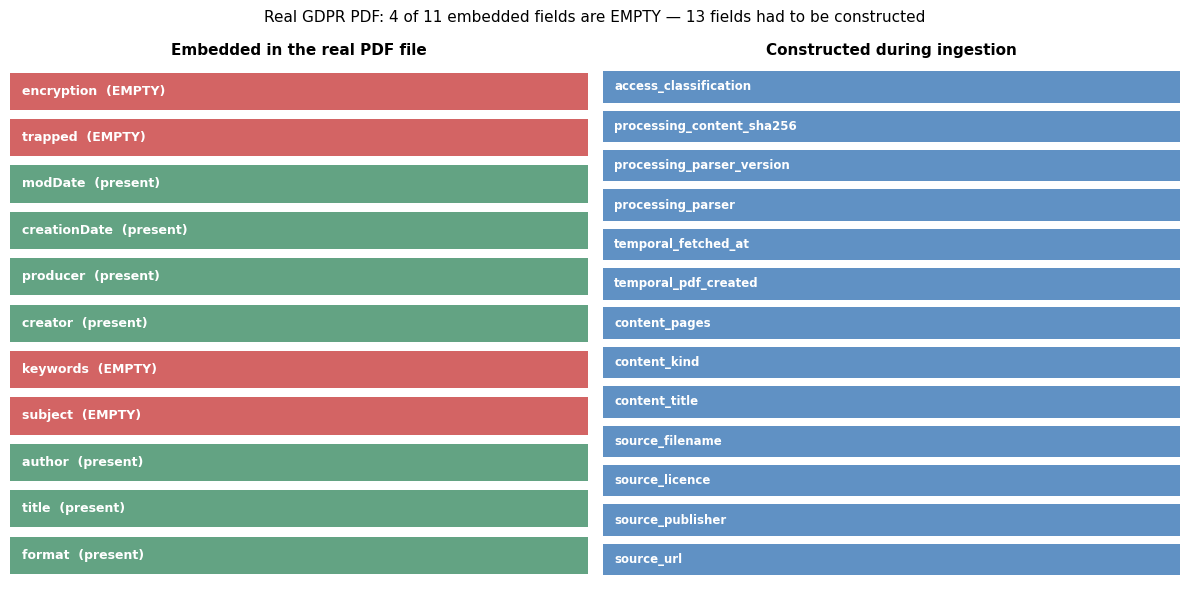

In [4]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    import matplotlib.pyplot as plt

    # Re-read the real embedded metadata to compare against the constructed record.
    document = pymupdf.open(gdpr_path)
    embedded_metadata = document.metadata
    document.close()

    # Classify each embedded field as present or empty, using the REAL values.
    embedded_fields = [(k, bool(v)) for k, v in embedded_metadata.items()]

    # Every field we constructed ourselves is, by definition, present.
    constructed_fields = [(k, True) for k in gdpr_metadata]

    figure, (left_axis, right_axis) = plt.subplots(1, 2, figsize=(12, 6))

    # LEFT - what the real PDF carried by itself.
    left_axis.set_title("Embedded in the real PDF file", fontsize=11, fontweight="bold")
    for index, (name, present) in enumerate(embedded_fields):
        colour = "#2f855a" if present else "#c53030"
        label = "present" if present else "EMPTY"
        left_axis.barh(index, 1, color=colour, alpha=0.75)
        left_axis.text(0.02, index, f"{name}  ({label})", va="center", fontsize=9,
                        color="white", fontweight="bold")
    left_axis.set_xlim(0, 1)
    left_axis.set_ylim(-0.6, len(embedded_fields) - 0.4)
    left_axis.axis("off")

    # RIGHT - what we constructed during ingestion.
    right_axis.set_title("Constructed during ingestion", fontsize=11, fontweight="bold")
    for index, (name, _) in enumerate(constructed_fields):
        right_axis.barh(index, 1, color="#2b6cb0", alpha=0.75)
        right_axis.text(0.02, index, name, va="center", fontsize=8.5,
                         color="white", fontweight="bold")
    right_axis.set_xlim(0, 1)
    right_axis.set_ylim(-0.6, len(constructed_fields) - 0.4)
    right_axis.axis("off")

    n_empty = sum(1 for _, present in embedded_fields if not present)
    plt.suptitle(
        f"Real GDPR PDF: {n_empty} of {len(embedded_fields)} embedded fields are EMPTY — "
        f"{len(constructed_fields)} fields had to be constructed",
        fontsize=11,
    )
    plt.tight_layout()
    plt.show()

**Red is what the real file failed to provide.** The right-hand column is the ingestion
pipeline's actual job — and none of those values can be recovered later if you do not record
them at fetch time.

# 3. Chunk-level metadata: the structural layer

**The intuition before the code.** Document-level metadata is the same for every chunk in the
file, so it is cheap. Structural metadata is the opposite: it is different for every chunk, it
is what makes a citation *specific*, and it is only available while you still have the
document open. Once you have a flat list of text strings, page numbers are gone forever.

```mermaid
flowchart TD
    A["Document metadata\n(same for all chunks)"] --> C["Merged chunk record"]
    B["Structural metadata\n(different per chunk:\npage, index, char span)"] --> C
    C --> D["Every chunk is\nindependently citable"]
```

![Diagram](diagrams/cell10-296f1f61e0.svg)



In [5]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Define a function that produces chunk records carrying BOTH metadata layers.
    def chunk_pdf_with_metadata(local_path, document_metadata, max_chars=600):

        document = pymupdf.open(local_path)
        chunk_records = []

        # Walk real pages - the page number only exists while we are in this loop.
        for page_index in range(len(document)):

            page = document.load_page(page_index)
            page_text = page.get_text("text")

            # Split this page's text into chunks of roughly max_chars.
            position = 0
            chunk_index_on_page = 0
            while position < len(page_text):

                chunk_text = page_text[position:position + max_chars].strip()

                if chunk_text:
                    chunk_records.append({
                        # STRUCTURAL - unique to this chunk, unrecoverable later.
                        "page_number": page_index + 1,
                        "chunk_index_on_page": chunk_index_on_page,
                        "char_start": position,
                        "char_end": position + len(chunk_text),
                        "text": chunk_text,

                        # Carry the document-level record forward on every chunk.
                        **{k: v for k, v in document_metadata.items()},
                    })
                    chunk_index_on_page += 1

                position += max_chars

        document.close()
        return chunk_records


    # Build real chunks from the first 12 pages only, to keep the run fast.
    document = pymupdf.open(gdpr_path)
    total_pages = len(document)
    document.close()

    gdpr_chunks = chunk_pdf_with_metadata(gdpr_path, gdpr_metadata)

    print(f"Real chunks produced from {total_pages} real pages: {len(gdpr_chunks):,}\n")
    print("One real chunk record, every field it carries:\n")
    sample_chunk = gdpr_chunks[120]
    for key, value in sample_chunk.items():
        display = str(value).replace("\n", " ")
        if len(display) > 60:
            display = display[:57] + "..."
        print(f"  {key:<28} {display}")

Real chunks produced from 88 real pages: 647

One real chunk record, every field it carries:

  page_number                  14
  chunk_index_on_page          2
  char_start                   1200
  char_end                     1800
  text                         ions, standards and recommendations of  Union institution...
  source_url                   https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=C...
  source_publisher             EUR-Lex, CELEX 32016R0679
  source_licence               © European Union, reuse permitted (Decision 2011/833/EU)
  source_filename              gdpr_regulation_2016_679.pdf
  content_title                REGULATION  (EU)  2016/  679  OF  THE  EUROPEAN  PARLIAME...
  content_kind                 pdf
  content_pages                88
  temporal_pdf_created         D:20160502113414+02'00'
  temporal_fetched_at          2026-09-18T10:14:52+00:00
  processing_parser            pymupdf
  processing_parser_version    1.28.2:
  processing_content_sha256

That chunk can now be cited precisely: page number, exact character span, source URL,
licence, and the hash of the file it came from. Compare that to a bare string of text, which
can only be quoted, never verified.

# 4. What metadata filtering actually buys you

**The intuition before the code.** The argument for metadata is usually made hand-wavingly
("it improves retrieval"). Let's measure it instead. Take a real query, retrieve naively
across the whole document, then retrieve again with a metadata filter, and count how many
results were irrelevant in each case.

In [6]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # A realistic question a user would actually ask of the GDPR.
    query_terms = ["erasure", "forgotten"]

    # NAIVE retrieval: scan every chunk for the query terms, no filtering.
    naive_hits = [
        chunk for chunk in gdpr_chunks
        if any(term in chunk["text"].lower() for term in query_terms)
    ]

    # FILTERED retrieval: same search, but restricted to the pages where the
    # substantive articles live - a real structural metadata filter.
    ARTICLE_PAGE_MIN, ARTICLE_PAGE_MAX = 32, 60
    filtered_hits = [
        chunk for chunk in naive_hits
        if ARTICLE_PAGE_MIN <= chunk["page_number"] <= ARTICLE_PAGE_MAX
    ]

    print(f"Query terms: {query_terms}\n")
    print(f"  Naive scan (no metadata filter) : {len(naive_hits):3d} chunks matched")
    print(f"  With page-range metadata filter : {len(filtered_hits):3d} chunks matched")
    print(f"  Chunks eliminated by filtering  : {len(naive_hits) - len(filtered_hits):3d}")

    print("\nPages the naive scan pulled from (note the spread across the whole document):")
    naive_pages = sorted({c["page_number"] for c in naive_hits})
    print(f"  {naive_pages}")

    print("\nPages the filtered search pulled from:")
    filtered_pages = sorted({c["page_number"] for c in filtered_hits})
    print(f"  {filtered_pages}")

Query terms: ['erasure', 'forgotten']

  Naive scan (no metadata filter) :  18 chunks matched
  With page-range metadata filter :  10 chunks matched
  Chunks eliminated by filtering  :   8

Pages the naive scan pulled from (note the spread across the whole document):
  [7, 11, 12, 13, 14, 29, 33, 41, 42, 43, 44, 45, 51, 70]

Pages the filtered search pulled from:
  [33, 41, 42, 43, 44, 45, 51]


The naive scan matches chunks scattered across the whole document — including the recitals
(the long non-binding preamble) and the table of contents, which mention "erasure" without
*being* the rule about erasure. The page filter removes those. **That is precision bought with
one metadata field**, before any embedding model is involved at all.

## 4.1 Seeing where the matches actually landed

Let's plot the real page positions of both result sets, so the filtering effect is visible
rather than described.

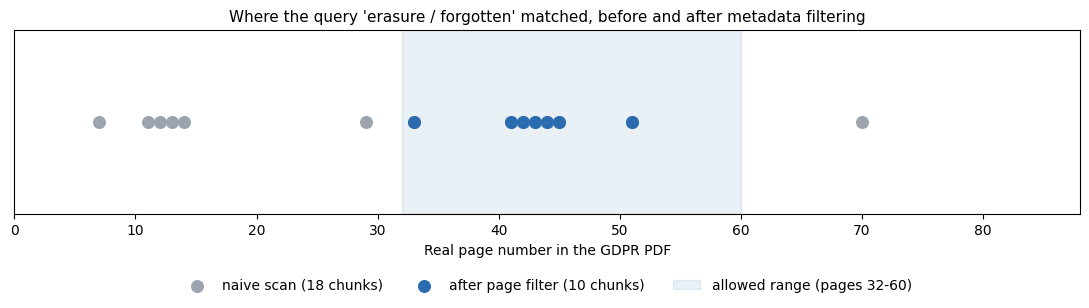

In [7]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    import matplotlib.pyplot as plt

    figure, axis = plt.subplots(figsize=(11, 3.4))

    # Plot every naive hit as a grey tick at its real page number.
    axis.scatter(naive_pages, [1] * len(naive_pages), s=70, color="#9ca3af",
                  label=f"naive scan ({len(naive_hits)} chunks)", zorder=2)

    # Plot the filtered hits on top, in blue, at their real page numbers.
    axis.scatter(filtered_pages, [1] * len(filtered_pages), s=70, color="#2b6cb0",
                  label=f"after page filter ({len(filtered_hits)} chunks)", zorder=3)

    # Shade the allowed page range so the filter's effect is obvious.
    axis.axvspan(ARTICLE_PAGE_MIN, ARTICLE_PAGE_MAX, color="#2b6cb0", alpha=0.10,
                  label=f"allowed range (pages {ARTICLE_PAGE_MIN}-{ARTICLE_PAGE_MAX})")

    axis.set_xlim(0, total_pages)
    axis.set_yticks([])
    axis.set_xlabel("Real page number in the GDPR PDF")
    axis.set_title(
        "Where the query 'erasure / forgotten' matched, before and after metadata filtering",
        fontsize=11,
    )
    axis.legend(loc="upper center", bbox_to_anchor=(0.5, -0.28), ncol=3, frameon=False)
    plt.tight_layout()
    plt.show()

**Grey dots outside the shaded band are the false positives metadata removed** — real
matches on the literal words, in parts of the document that do not answer the question. No
embedding model was needed to eliminate them.

# 5. Provenance: the citation chain

**The intuition before the code.** Provenance is metadata's most demanding use case: it must
survive *every* transformation, from raw bytes to the sentence in the final answer. If any
stage drops it, the answer becomes uncitable. The test is simple — given only the final
answer object, can you get back to the exact source bytes?

```mermaid
flowchart LR
    A["Source URL"] --> B["Fetched file\n+ sha256"]
    B --> C["Parsed page\n+ page number"]
    C --> D["Chunk\n+ char span"]
    D --> E["Retrieved result"]
    E --> F["Answer citation"]
    F -.->|"must resolve back to"| A
```

![Diagram](diagrams/cell16-cff86ca514.svg)



In [8]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # Define a function that renders a full, human-readable citation from a chunk record.
    def build_citation(chunk):

        return (
            f"{chunk['content_title']}, "
            f"page {chunk['page_number']} "
            f"(chars {chunk['char_start']}-{chunk['char_end']}). "
            f"Source: {chunk['source_url']} "
            f"[{chunk['source_publisher']}, {chunk['source_licence']}]. "
            f"Retrieved {chunk['temporal_fetched_at']}, "
            f"file sha256 {chunk['processing_content_sha256'][:12]}..., "
            f"parsed with {chunk['processing_parser']}."
        )


    # Take a real retrieved chunk and produce its real citation.
    if filtered_hits:
        cited_chunk = filtered_hits[0]

        print("The retrieved text:\n")
        print(f"  {cited_chunk['text'][:200]}...\n")

        print("Its full provenance citation:\n")
        print(f"  {build_citation(cited_chunk)}")

The retrieved text:

  g’ means any operation or set of operations which is performed on personal data or on sets of personal 
data, whether or not by automated means, such as collection, recording, organisation, structurin...

Its full provenance citation:

  REGULATION  (EU)  2016/  679  OF  THE  EUROPEAN  PARLIAMENT  AND  OF  THE  COUNCIL  -  of  27  April  2016  -  on  the  protection  of  natural  persons  with  regard  to  the  processing  of  personal  data  and  on  the  free  movement  of  such  data,  and  repealing  Directive 95/  46/  EC  (General  Data  Protection  Regulation), page 33 (chars 1200-1799). Source: https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679 [EUR-Lex, CELEX 32016R0679, © European Union, reuse permitted (Decision 2011/833/EU)]. Retrieved 2026-09-18T10:14:52+00:00, file sha256 bd84e63f5b62..., parsed with pymupdf.


Every element of that citation traces back to a real fact recorded during ingestion. The
sha256 in particular means a reader can verify the exact file — not "the GDPR", but *that
byte-identical copy of the GDPR*.

# 6. Deterministic vs LLM metadata extraction

**The intuition before the code.** Some metadata is a fact you can compute (page number, file
hash, fetch time, character count). Some is a judgement (topic, summary, sensitivity). The
first kind must never be done with an LLM — it would be slower, more expensive, and
occasionally wrong about something that was never uncertain. The second kind cannot be done
without one.

```mermaid
flowchart TD
    A["Metadata field"] --> B{"Is it computable\nfrom the bytes?"}
    B -->|"yes: page, hash, dates,\nlength, language"| C["Deterministic code.\nFast, free, always correct."]
    B -->|"no: topic, summary,\nsensitivity, entities"| D["LLM extraction.\nSlow, costs money,\nneeds validation."]
    C --> E["Chunk record"]
    D --> E
```

![Diagram](diagrams/cell18-30e3294c4f.svg)

| Field | Extract with | Why |
|---|---|---|
| page number, char span | **Code** | Exact, free, cannot be wrong |
| sha256, file size, fetch time | **Code** | Facts about bytes and clocks |
| language | **Code** (`langdetect`) | Statistical, reliable, no LLM needed |
| document type (invoice/contract) | Code if the format is fixed, else **LLM** | A rule works until the format varies |
| topic, one-line summary | **LLM** | A judgement about meaning |
| sensitivity / PII presence | **LLM**, then human review | High-stakes judgement, must be validated |

Let's do the deterministic half on the real document and see how far code alone gets you.

In [9]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    import re

    # Define a function that derives content metadata using only deterministic code.
    def derive_content_metadata(chunk):

        text = chunk["text"]

        # Count real words and characters - exact, no model needed.
        word_count = len(text.split())

        # Detect real article references with a regex - the GDPR's own numbering scheme.
        article_references = re.findall(r"Article\s+(\d+)", text)

        # Detect whether this chunk contains a real date reference.
        has_date = bool(re.search(r"\b(19|20)\d{2}\b", text))

        # Crude but deterministic language signal: count stopwords of each language.
        english_markers = sum(1 for w in ["the", "of", "and", "shall"] if f" {w} " in text.lower())

        return {
            "derived_word_count": word_count,
            "derived_article_refs": sorted(set(article_references), key=int),
            "derived_has_date": has_date,
            "derived_english_score": english_markers,
        }


    # Apply it to real chunks and show what code alone extracted.
    print("Deterministic content metadata from real chunks:\n")
    for chunk in filtered_hits[:4]:
        derived = derive_content_metadata(chunk)
        print(f"  page {chunk['page_number']:3d}  "
              f"words={derived['derived_word_count']:3d}  "
              f"articles={derived['derived_article_refs']}  "
              f"has_date={derived['derived_has_date']}")

    # Report how many real chunks reference an article at all.
    with_refs = sum(1 for c in gdpr_chunks if derive_content_metadata(c)["derived_article_refs"])
    print(f"\nReal chunks containing an explicit Article reference: "
          f"{with_refs:,} of {len(gdpr_chunks):,} ({with_refs/len(gdpr_chunks):.0%})")

Deterministic content metadata from real chunks:

  page  33  words= 84  articles=[]  has_date=False
  page  41  words=101  articles=[]  has_date=False
  page  42  words=102  articles=['6']  has_date=False
  page  43  words= 94  articles=[]  has_date=False

Real chunks containing an explicit Article reference: 224 of 647 (35%)


No LLM was called, no API key was needed, and the article-reference extraction is exactly
correct because "Article 17" is a literal string, not a judgement. **Reach for an LLM only
after you have exhausted what code can do for free.**

# 7. End-to-end: one real document, full metadata pipeline

Fetch, hash, parse, chunk, attach all six metadata categories, filter, and cite — one real
document, one unbroken run.

In [10]:
# Only run if PyMuPDF is available.
if pymupdf is not None:

    # STEP 1 - fetch the real source document.
    end_to_end_path = fetch("gdpr_pdf", quiet=True)

    # STEP 2 - build the document-level metadata record (source, temporal, processing).
    end_to_end_doc_metadata = build_document_metadata("gdpr_pdf", end_to_end_path)

    # STEP 3 - chunk the real document, attaching structural metadata per chunk.
    end_to_end_chunks = chunk_pdf_with_metadata(end_to_end_path, end_to_end_doc_metadata)

    # STEP 4 - enrich every chunk with deterministic content metadata.
    for chunk in end_to_end_chunks:
        chunk.update(derive_content_metadata(chunk))

    # STEP 5 - apply a real metadata filter: substantive article pages only.
    end_to_end_filtered = [
        c for c in end_to_end_chunks
        if ARTICLE_PAGE_MIN <= c["page_number"] <= ARTICLE_PAGE_MAX
        and c["derived_article_refs"]
    ]

    print(f"STEP 3 - chunks produced          : {len(end_to_end_chunks):,}")
    print(f"STEP 5 - after metadata filtering : {len(end_to_end_filtered):,}")
    print(f"         eliminated               : "
          f"{len(end_to_end_chunks) - len(end_to_end_filtered):,} chunks\n")

    print("STEP 6 - one final record, complete with citation:\n")
    final_record = end_to_end_filtered[0]
    print(f"  text     : {final_record['text'][:120]}...")
    print(f"  articles : {final_record['derived_article_refs']}")
    print(f"  citation : {build_citation(final_record)}")

STEP 3 - chunks produced          : 647
STEP 5 - after metadata filtering : 103
         eliminated               : 544 chunks

STEP 6 - one final record, complete with citation:

  text     : HAVE ADOPTED THIS REGULATION: 
CHAPTER I 
General provisions 
Article 1 
Subject-matter and objectives 
1.
This Regulati...
  articles : ['1']
  citation : REGULATION  (EU)  2016/  679  OF  THE  EUROPEAN  PARLIAMENT  AND  OF  THE  COUNCIL  -  of  27  April  2016  -  on  the  protection  of  natural  persons  with  regard  to  the  processing  of  personal  data  and  on  the  free  movement  of  such  data,  and  repealing  Directive 95/  46/  EC  (General  Data  Protection  Regulation), page 32 (chars 0-600). Source: https://eur-lex.europa.eu/legal-content/EN/TXT/PDF/?uri=CELEX:32016R0679 [EUR-Lex, CELEX 32016R0679, © European Union, reuse permitted (Decision 2011/833/EU)]. Retrieved 2026-09-18T10:47:35+00:00, file sha256 bd84e63f5b62..., parsed with pymupdf.


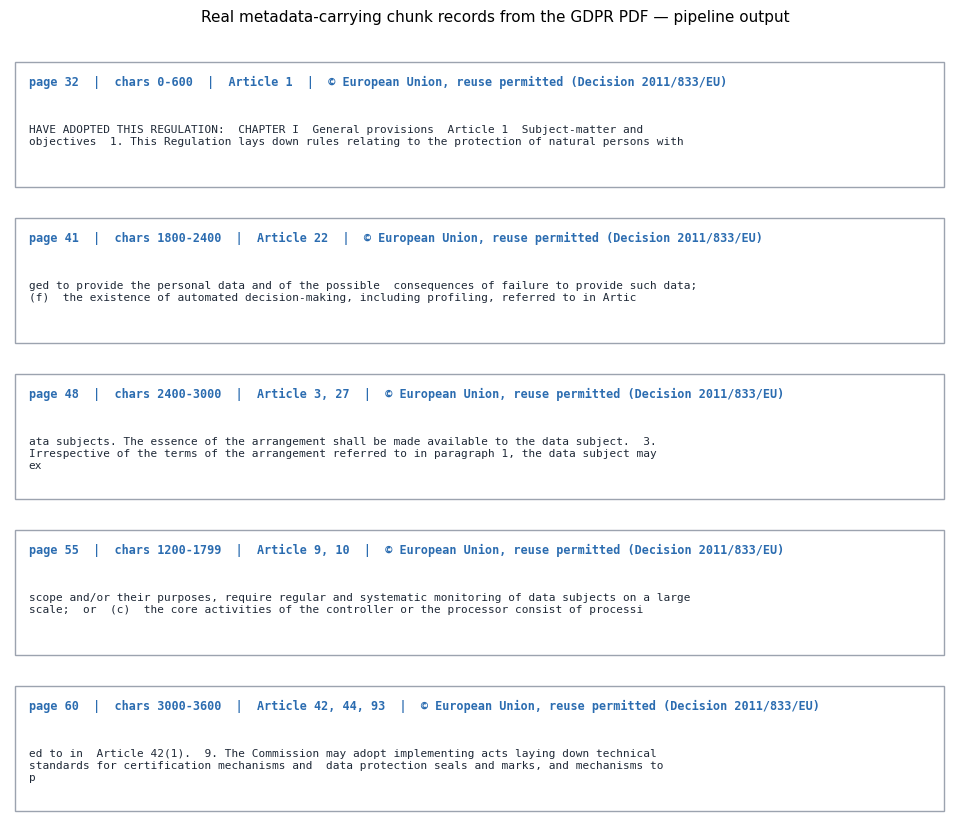

In [11]:
# Render the final metadata-carrying records as real cards, not just printed text.
if pymupdf is not None:

    import matplotlib.pyplot as plt
    import textwrap

    # Pick real records spread across the filtered set.
    n = len(end_to_end_filtered)
    card_indices = sorted(set([0, n // 4, n // 2, n * 3 // 4, n - 1]))
    card_records = [end_to_end_filtered[i] for i in card_indices]

    figure, axes = plt.subplots(len(card_records), 1, figsize=(10, 1.65 * len(card_records)))
    for axis, record in zip(axes, card_records):

        axis.axis("off")
        axis.set_xlim(0, 1)
        axis.set_ylim(0, 1)
        axis.add_patch(plt.Rectangle((0.005, 0.06), 0.99, 0.88, fill=False,
                                       edgecolor="#9ca3af", linewidth=1))

        # The metadata strip - this is what makes the chunk citable.
        axis.text(0.02, 0.78,
                    f"page {record['page_number']}  |  chars "
                    f"{record['char_start']}-{record['char_end']}  |  "
                    f"Article {', '.join(record['derived_article_refs'])}  |  "
                    f"{record['source_licence']}",
                    fontsize=8.5, color="#2b6cb0", fontweight="bold", family="monospace")

        # The real chunk text below it.
        axis.text(0.02, 0.5, textwrap.fill(record["text"].replace("\n", " "), width=100)[:190],
                    fontsize=8, color="#1f2937", family="monospace", va="top")

    plt.suptitle("Real metadata-carrying chunk records from the GDPR PDF — pipeline output",
                  fontsize=11, y=1.0)
    plt.tight_layout()
    plt.show()

# 8. Module summary

## Key points

1. **Six categories**: source, structural, content, temporal, access, processing. Store the
   field even when the value is trivial today — adding it retroactively is impossible.
2. **Real files carry almost no usable embedded metadata.** Construct it at ingestion; the
   facts you do not record at fetch time are gone permanently.
3. **Structural metadata only exists while the document is open.** Page numbers cannot be
   recovered from a list of strings.
4. **Filtering on metadata buys precision for free**, before any embedding is involved.
5. **Provenance must survive every stage.** The test: can you get from the final citation back
   to the exact source bytes? The sha256 is what makes that verifiable.
6. **Compute what is computable; reserve the LLM for judgements.** Page numbers and hashes are
   never an LLM's job.

## Interview answer: "What metadata do you attach to a chunk?"

> Six categories: source (URL, publisher, licence), structural (page, section, character
> span), content (language, type, extracted references), temporal (created, fetched,
> valid-until), access (classification, allowed roles), and processing (parser, parser version,
> OCR confidence). The structural layer is the one people forget, and it is unrecoverable
> later — once you have a list of strings, the page numbers are gone. I record a sha256 of the
> source file so I can detect upstream changes and re-index only what actually moved, and I
> compute everything computable in code, reserving LLM extraction for genuine judgements like
> topic or sensitivity.

## Exercises

1. **Add access control.** Extend `build_document_metadata` with `allowed_roles`, and write a
   retrieval function that filters chunks by a caller's role before returning them.
2. **Detect a changed source.** Re-fetch a document, compare the new sha256 against the stored
   one, and report which chunks would need re-indexing.
3. **Language metadata.** Replace the crude `derived_english_score` with a real detector
   (`langdetect` or `fasttext`) and measure how they disagree on short chunks.
4. **Staleness policy.** Add a `valid_until` field and write a function that reports what
   fraction of an index is stale on a given date.

## Next: [Module 2g — Cleaning & Normalization](../2g.%20Cleaning%20and%20normalization/)

Metadata describes the text. Next: fixing the text itself — whitespace, hyphenation, Unicode
and repeated headers — without deleting real content by accident.